In [1]:

# import chardet

# # Read a sample of the file (or the whole file)
# with open('./data/data.csv', 'rb') as f:
#     rawdata = f.read()  # you can also read a chunk, e.g., f.read(100000)
    
# result = chardet.detect(rawdata)
# print(result)

In [2]:
print("kdf")

kdf


In [35]:
import pandas as pd
data = pd.read_csv('./data/data.csv')
data.head()

,airline,overall,author,review_date,customer_review,aircraft,traveller_type,cabin,route,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,âœ… Trip Verified | London to Izmir via Istanb...,NaN,Business,Economy Class,London to Izmir via Istanbul,May-19,4.0,5.0,4.0,4.0,2.0,4.0,yes
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,âœ… Trip Verified | Istanbul to Bucharest. We ...,NaN,Family Leisure,Economy Class,Istanbul to Bucharest,May-19,4.0,1.0,1.0,1.0,1.0,1.0,no
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
data.shape

(131895, 17)

In [37]:
data = data.dropna(how='all', axis=0)

In [38]:
data.head()

,airline,overall,author,review_date,customer_review,aircraft,traveller_type,cabin,route,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
1,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,âœ… Trip Verified | London to Izmir via Istanb...,NaN,Business,Economy Class,London to Izmir via Istanbul,May-19,4.0,5.0,4.0,4.0,2.0,4.0,yes
3,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,âœ… Trip Verified | Istanbul to Bucharest. We ...,NaN,Family Leisure,Economy Class,Istanbul to Bucharest,May-19,4.0,1.0,1.0,1.0,1.0,1.0,no
5,Turkish Airlines,3.0,M Galerko,7th May 2019,âœ… Trip Verified | Rome to Prishtina via Ista...,NaN,Business,Economy Class,Rome to Prishtina via Istanbul,May-19,1.0,4.0,1.0,3.0,1.0,2.0,no
7,Turkish Airlines,10.0,Zeshan Shah,6th May 2019,âœ… Trip Verified | Flew on Turkish Airlines I...,A330,Solo Leisure,Economy Class,Washington Dulles to Karachi,April 2019,4.0,5.0,5.0,5.0,5.0,5.0,yes
9,Turkish Airlines,1.0,Pooja Jain,6th May 2019,âœ… Trip Verified | Mumbai to Dublin via Istan...,NaN,Solo Leisure,Economy Class,Mumbai to Dublin via Istanbul,May-19,1.0,1.0,1.0,1.0,1.0,1.0,no


In [39]:
data.shape

(65947, 17)

In [40]:
data.info()

<class 'pandas.DataFrame'>
Index: 65947 entries, 1 to 131894
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          65947 non-null  str    
 1   overall          64017 non-null  float64
 2   author           65947 non-null  str    
 3   review_date      65947 non-null  str    
 4   customer_review  65947 non-null  str    
 5   aircraft         19718 non-null  str    
 6   traveller_type   39755 non-null  str    
 7   cabin            63303 non-null  str    
 8   route            39726 non-null  str    
 9   date_flown       39633 non-null  str    
 10  seat_comfort     60681 non-null  float64
 11  cabin_service    60715 non-null  float64
 12  food_bev         52608 non-null  float64
 13  entertainment    44193 non-null  float64
 14  ground_service   39358 non-null  float64
 15  value_for_money  63975 non-null  float64
 16  recommended      64440 non-null  str    
dtypes: float64(7), str(10)
memo

In [41]:
def Columns_Info(data):
    """
    Display a table showing the number of unique values for each column in the DataFrame.
    """
    unique_counts = {
        "Column": data.columns,
        "Unique Values": [data[col].nunique() for col in data.columns],
        'null values': [data[col].isna().sum() for col in data.columns]
    }
    
    result_df = pd.DataFrame(unique_counts)
    display(result_df)
Columns_Info(data)

,Column,Unique Values,null values
0,airline,81,0
1,overall,10,1930
2,author,44069,0
3,review_date,3015,0
4,customer_review,61172,0
5,aircraft,2088,46229
6,traveller_type,4,26192
7,cabin,4,2644
8,route,24549,26221
9,date_flown,63,26314


In [42]:
# drop columns if they exist (avoid KeyError if any are missing)
data = data.drop(['author', 'review_date', 'aircraft', 'route', 'date_flown'], axis=1, errors='ignore')

## copy of data 

In [43]:
df = data.copy()

In [44]:
df.head()

,airline,overall,customer_review,traveller_type,cabin,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
1,Turkish Airlines,7.0,âœ… Trip Verified | London to Izmir via Istanb...,Business,Economy Class,4.0,5.0,4.0,4.0,2.0,4.0,yes
3,Turkish Airlines,2.0,âœ… Trip Verified | Istanbul to Bucharest. We ...,Family Leisure,Economy Class,4.0,1.0,1.0,1.0,1.0,1.0,no
5,Turkish Airlines,3.0,âœ… Trip Verified | Rome to Prishtina via Ista...,Business,Economy Class,1.0,4.0,1.0,3.0,1.0,2.0,no
7,Turkish Airlines,10.0,âœ… Trip Verified | Flew on Turkish Airlines I...,Solo Leisure,Economy Class,4.0,5.0,5.0,5.0,5.0,5.0,yes
9,Turkish Airlines,1.0,âœ… Trip Verified | Mumbai to Dublin via Istan...,Solo Leisure,Economy Class,1.0,1.0,1.0,1.0,1.0,1.0,no


In [45]:
df.shape

(65947, 12)

In [46]:
df.info()

<class 'pandas.DataFrame'>
Index: 65947 entries, 1 to 131894
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          65947 non-null  str    
 1   overall          64017 non-null  float64
 2   customer_review  65947 non-null  str    
 3   traveller_type   39755 non-null  str    
 4   cabin            63303 non-null  str    
 5   seat_comfort     60681 non-null  float64
 6   cabin_service    60715 non-null  float64
 7   food_bev         52608 non-null  float64
 8   entertainment    44193 non-null  float64
 9   ground_service   39358 non-null  float64
 10  value_for_money  63975 non-null  float64
 11  recommended      64440 non-null  str    
dtypes: float64(7), str(5)
memory usage: 6.5 MB


In [47]:
import pandas as pd

# Remove rows where 'recommended' is null
df = df.dropna(subset=['recommended'])

# List of numeric rating columns
numeric_cols = [
    'overall', 'seat_comfort', 'cabin_service', 
    'food_bev', 'entertainment', 'ground_service', 'value_for_money'
]

# Fill missing numeric columns with mean
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# List of categorical/text columns (excluding 'recommended' which is already filled)
categorical_cols = ['traveller_type', 'cabin']

# Fill missing categorical/text columns with 'Unknown'
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

# Optional: check final nulls
print(df.isnull().sum())


airline            0
overall            0
customer_review    0
traveller_type     0
cabin              0
seat_comfort       0
cabin_service      0
food_bev           0
entertainment      0
ground_service     0
value_for_money    0
recommended        0
dtype: int64


In [48]:
import re
import string

# Function to clean text
def clean_text(text):
    if pd.isnull(text):
        return ""  
    text = text.lower()  
    text = text.translate(str.maketrans('', '', string.punctuation))  
    text = re.sub(r'[^\x00-\x7F]+', '', text)  # remove non-ASCII characters
    return text

df['customer_review'] = df['customer_review'].apply(clean_text)

# Check the result in below cell//.////..///.....1

In [49]:
df['customer_review'].head(10)

1      trip verified  london to izmir via istanbul f...
3      trip verified  istanbul to bucharest we make ...
5      trip verified  rome to prishtina via istanbul...
7      trip verified  flew on turkish airlines iadis...
9      trip verified  mumbai to dublin via istanbul ...
11     trip verified  istanbul to budapest via dubli...
13     trip verified  istanbul to algiers planned to...
15     trip verified  basel to cape town via istanbu...
17    not verified  abu dhabi to luxembourg via ista...
19     trip verified  the experience with turkish ai...
Name: customer_review, dtype: str

#### let's see is  there any non encodded word after perform this string remove operation using re

In [50]:
df.head()

,airline,overall,customer_review,traveller_type,cabin,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
1,Turkish Airlines,7.0,trip verified london to izmir via istanbul f...,Business,Economy Class,4.0,5.0,4.0,4.0,2.0,4.0,yes
3,Turkish Airlines,2.0,trip verified istanbul to bucharest we make ...,Family Leisure,Economy Class,4.0,1.0,1.0,1.0,1.0,1.0,no
5,Turkish Airlines,3.0,trip verified rome to prishtina via istanbul...,Business,Economy Class,1.0,4.0,1.0,3.0,1.0,2.0,no
7,Turkish Airlines,10.0,trip verified flew on turkish airlines iadis...,Solo Leisure,Economy Class,4.0,5.0,5.0,5.0,5.0,5.0,yes
9,Turkish Airlines,1.0,trip verified mumbai to dublin via istanbul ...,Solo Leisure,Economy Class,1.0,1.0,1.0,1.0,1.0,1.0,no


In [51]:
# One-hot encode categorical columns except 'recommended'
categorical_cols = ['airline', 'traveller_type', 'cabin']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [52]:
df.columns

Index(['overall', 'customer_review', 'seat_comfort', 'cabin_service',
       'food_bev', 'entertainment', 'ground_service', 'value_for_money',
       'recommended', 'airline_Adria Airways', 'airline_Aegean Airlines',
       'airline_Aer Lingus', 'airline_Aeroflot Russian Airlines',
       'airline_Aeromexico', 'airline_Air Arabia', 'airline_Air Canada',
       'airline_Air Canada rouge', 'airline_Air China', 'airline_Air Europa',
       'airline_Air France', 'airline_Air India', 'airline_Air New Zealand',
       'airline_AirAsia', 'airline_Alaska Airlines', 'airline_Alitalia',
       'airline_American Airlines', 'airline_Asiana Airlines',
       'airline_Austrian Airlines', 'airline_Avianca',
       'airline_Bangkok Airways', 'airline_British Airways',
       'airline_Brussels Airlines', 'airline_Cathay Pacific Airways',
       'airline_China Eastern Airlines', 'airline_China Southern Airlines',
       'airline_Copa Airlines', 'airline_Delta Air Lines', 'airline_EVA Air',
       'airli

In [53]:
# Convert 'recommended' to 0/1 if not already
df['recommended'] = df['recommended'].map({'no': 0, 'yes': 1})

In [54]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Create the TF-IDF features
tfidf = TfidfVectorizer(max_features=5000)
X_text = tfidf.fit_transform(df['customer_review'])

# 2. Convert sparse matrix to DataFrame
df_text = pd.DataFrame(X_text.toarray(), columns=tfidf.get_feature_names_out())

# 3. Reset index to avoid misalignment
df_reset = df.reset_index(drop=True)
df_text_reset = df_text.reset_index(drop=True)

# 4. Concatenate the original DataFrame and the TF-IDF DataFrame
df_combined = pd.concat([df_reset, df_text_reset], axis=1)

df_combined.head()

,overall,customer_review,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended,airline_Adria Airways,...,yvr,yyz,zagreb,zealand,zero,zone,zones,zrh,zrich,zurich
0,7.0,trip verified london to izmir via istanbul f...,4.0,5.0,4.0,4.0,2.0,4.0,1,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,trip verified istanbul to bucharest we make ...,4.0,1.0,1.0,1.0,1.0,1.0,0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,trip verified rome to prishtina via istanbul...,1.0,4.0,1.0,3.0,1.0,2.0,0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10.0,trip verified flew on turkish airlines iadis...,4.0,5.0,5.0,5.0,5.0,5.0,1,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,trip verified mumbai to dublin via istanbul ...,1.0,1.0,1.0,1.0,1.0,1.0,0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
# Check the types of all columns
print(df_combined.dtypes)

# Check only the first few TF-IDF columns
tfidf_cols = df_combined.columns[-5000:]  # assuming TF-IDF are the last 5000 columns
df_combined[tfidf_cols].head()



overall            float64
customer_review        str
seat_comfort       float64
cabin_service      float64
food_bev           float64
                    ...   
zone               float64
zones              float64
zrh                float64
zrich              float64
zurich             float64
Length: 5097, dtype: object


,10,100,1000,10000,1010,1015,1030,1030pm,105,10am,...,yvr,yyz,zagreb,zealand,zero,zone,zones,zrh,zrich,zurich
0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.04839,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
df_final = df_combined.drop('customer_review', axis=1)

# Drop any duplicate columns (e.g. 'recommended' may appear in TF-IDF vocab too)
df_final = df_final.loc[:, ~df_final.columns.duplicated(keep='first')]

print("df_final shape:", df_final.shape)
print("Duplicate columns:", df_final.columns[df_final.columns.duplicated()].tolist())


df_final shape: (64440, 5093)
Duplicate columns: []


In [57]:
df_final.head()

,overall,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended,airline_Adria Airways,airline_Aegean Airlines,...,yvr,yyz,zagreb,zealand,zero,zone,zones,zrh,zrich,zurich
0,7.0,4.0,5.0,4.0,4.0,2.0,4.0,1,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,4.0,1.0,1.0,1.0,1.0,1.0,0,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,1.0,4.0,1.0,3.0,1.0,2.0,0,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10.0,4.0,5.0,5.0,5.0,5.0,5.0,1,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
df_final.columns

Index(['overall', 'seat_comfort', 'cabin_service', 'food_bev', 'entertainment',
       'ground_service', 'value_for_money', 'recommended',
       'airline_Adria Airways', 'airline_Aegean Airlines',
       ...
       'yvr', 'yyz', 'zagreb', 'zealand', 'zero', 'zone', 'zones', 'zrh',
       'zrich', 'zurich'],
      dtype='str', length=5093)

In [59]:
X = df_final.drop('recommended', axis=1)  # all numeric features
y = df_final['recommended']               # target


In [60]:
from scipy import sparse

# Example: numeric columns
numeric_cols = ['overall', 'seat_comfort', 'cabin_service', 
                'food_bev', 'entertainment', 'ground_service', 'value_for_money']

X_numeric = X[numeric_cols].astype('float32')

# One-hot / boolean columns
bool_cols = X.drop(columns=numeric_cols).columns
X_sparse = sparse.csr_matrix(X[bool_cols].astype('float32').values)


In [61]:
from scipy.sparse import hstack

X_final = hstack([X_numeric.values, X_sparse]).tocsr()

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)


In [63]:
y_train

64122    1
54578    0
11821    0
6537     1
10990    0
        ..
62570    1
38158    0
860      0
15795    1
56422    0
Name: recommended, Length: 51552, dtype: int64

## Model Building — Logistic Regression

In [64]:
y = df_final['recommended']

print("y shape:", y.shape)
print("y dtype:", y.dtype)
print("Class distribution:\n", y.value_counts())


y shape: (64440,)
y dtype: int64
Class distribution:
 recommended
0    33894
1    30546
Name: count, dtype: int64


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)
print("y_train type:", type(y_train), "| shape:", y_train.shape)


Train size: (51552, 5092)
Test  size: (12888, 5092)
y_train type: <class 'pandas.Series'> | shape: (51552,)


In [66]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
model.fit(X_train, y_train)

print("Training complete.")


Training complete.


In [67]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Classification report
print("=" * 50)
print("Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Not Recommended', 'Recommended']))

# AUC-ROC
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC Score: {auc:.4f}")


Classification Report
                 precision    recall  f1-score   support

Not Recommended       0.97      0.96      0.97      6779
    Recommended       0.96      0.96      0.96      6109

       accuracy                           0.96     12888
      macro avg       0.96      0.96      0.96     12888
   weighted avg       0.96      0.96      0.96     12888

AUC-ROC Score: 0.9930


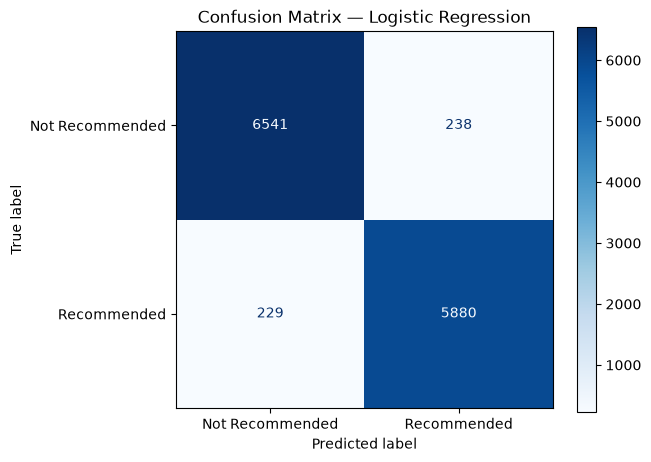

In [68]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Recommended', 'Recommended'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()


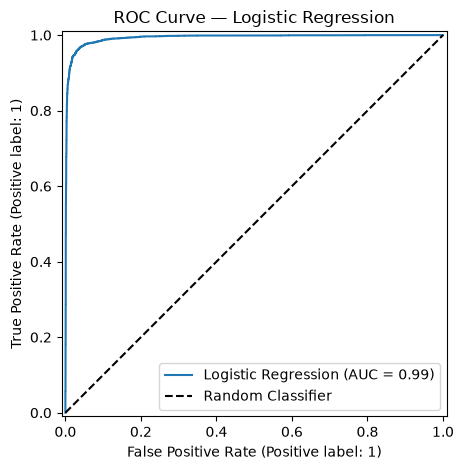

In [69]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba, name='Logistic Regression')
plt.title('ROC Curve — Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.tight_layout()
plt.show()


In [70]:
import numpy as np

# Summary verdict
accuracy = (y_pred == y_test).mean()
print("=" * 50)
print("Model Summary")
print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print(f"AUC-ROC  : {auc:.4f}")
print()
if auc >= 0.90:
    print("✅ Excellent model! AUC >= 0.90 — your model is ready.")
elif auc >= 0.80:
    print("✅ Good model! AUC >= 0.80 — solid baseline, consider tuning for more.")
else:
    print("⚠️  AUC below 0.80 — model needs improvement.")


Model Summary
Accuracy : 0.9638
AUC-ROC  : 0.9930

✅ Excellent model! AUC >= 0.90 — your model is ready.


In [71]:
import joblib

# Save the model and the TF-IDF vectorizer
joblib.dump(model, './data/logistic_regression_model.pkl')
joblib.dump(tfidf, './data/tfidf_vectorizer.pkl')

print("Model saved to ./data/logistic_regression_model.pkl")
print("TF-IDF vectorizer saved to ./data/tfidf_vectorizer.pkl")


Model saved to ./data/logistic_regression_model.pkl
TF-IDF vectorizer saved to ./data/tfidf_vectorizer.pkl


: 